In [1]:
import os

folder_path = "GpC26"

data = {}

'''
for file in os.listdir(folder_path):
    if file.endswith(".csv"):
        file_path = os.path.join(folder_path, file)
        data[file] = load_spectrum(file_path)
        '''

'\nfor file in os.listdir(folder_path):\n    if file.endswith(".csv"):\n        file_path = os.path.join(folder_path, file)\n        data[file] = load_spectrum(file_path)\n        '

In [2]:
import pandas as pd

def load_spectrum(file_path):
    with open(file_path, "r") as f:
        lines = f.readlines()

    start_row = None
    for i, line in enumerate(lines):
        if "Channel" in line:
            start_row = i
            break

    df = pd.read_csv(file_path, skiprows=start_row)

    df.columns = df.columns.str.strip().str.replace(",", "")
    df = df.iloc[:, :3]
    df.columns = ["Channel", "Energy", "Counts"]

    df = df[["Channel", "Counts"]]

    df["Channel"] = pd.to_numeric(df["Channel"], errors="coerce")
    df["Counts"] = pd.to_numeric(df["Counts"], errors="coerce")

    df = df.dropna()

    return df

In [3]:
angle_data = {}

angle_data[-6] = load_spectrum("GpC26/-6degrees.csv")
angle_data[-5] = load_spectrum("GpC26/-5degrees.csv")
angle_data[-4] = load_spectrum("GpC26/-4degrees.csv")
angle_data[-3] = load_spectrum("GpC26/-3degrees.csv")
angle_data[-2] = load_spectrum("GpC26/-2degrees.csv")
angle_data[-1] = load_spectrum("GpC26/-1degrees.csv")
angle_data[0] = load_spectrum("GpC26/0degrees.csv")
angle_data[1] = load_spectrum("GpC26/1degree.csv")
angle_data[2] = load_spectrum("GpC26/2degrees.csv")
angle_data[3] = load_spectrum("GpC26/3degrees.csv")
angle_data[4] = load_spectrum("GpC26/4degrees.csv")
angle_data[5] = load_spectrum("GpC26/5degrees.csv")
angle_data[6] = load_spectrum("GpC26/6degrees.csv")



In [4]:
poisson_68_table = {
    0: (0.0, 1.84),
    1: (0.17, 3.30),
    3: (1.37, 5.92),
    4: (2.09, 7.16),
    16: (12.04, 21.08),
    14: (10.03, 18.83),
}

,Angle (deg),Counts (N),Unc - (counts),Unc + (counts),Rate (counts/s),Unc - (counts/s),Unc + (counts/s)
0,-6,3,1.630,2.920,0.01000,0.00543,0.00973
1,-5,16,3.960,5.080,0.05333,0.01320,0.01693
2,-4,60,7.746,7.746,0.20000,0.02582,0.02582
3,-3,115,10.724,10.724,0.38333,0.03575,0.03575
4,-2,215,14.663,14.663,0.71667,0.04888,0.04888
5,-1,281,16.763,16.763,0.93667,0.05588,0.05588
6,0,285,16.882,16.882,0.95000,0.05627,0.05627
7,1,294,17.146,17.146,0.98000,0.05715,0.05715
8,2,250,15.811,15.811,0.83333,0.05270,0.05270
9,3,215,14.663,14.663,0.71667,0.04888,0.04888


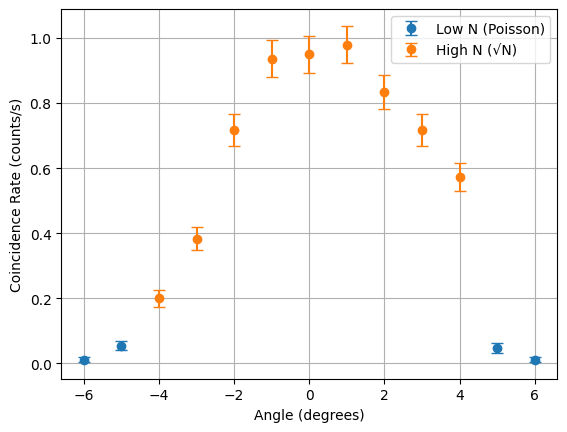

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

run_time = 300

low_angles, low_rates, low_err_low, low_err_high = [], [], [], []
high_angles, high_rates, high_err = [], [], []
rows = []

for angle, df in sorted(angle_data.items()):
    N = df[(df["Channel"].between(280, 350))]["Counts"].sum()
    R = N / run_time

    if N < 50 and N in poisson_68_table:
        low, high = poisson_68_table[N]
        e_low, e_high = (N - low)/run_time, (high - N)/run_time

        low_angles.append(angle)
        low_rates.append(R)
        low_err_low.append(e_low)
        low_err_high.append(e_high)

        unc_counts_low, unc_counts_high = N - low, high - N
        sigma_low, sigma_high = e_low, e_high

    else:
        e = np.sqrt(N)
        high_angles.append(angle)
        high_rates.append(R)
        high_err.append(e/run_time)

        unc_counts_low = unc_counts_high = e
        sigma_low = sigma_high = e / run_time

    rows.append({
        "Angle (deg)": angle,
        "Counts (N)": int(N),
        "Unc - (counts)": round(unc_counts_low, 3),
        "Unc + (counts)": round(unc_counts_high, 3),
        "Rate (counts/s)": round(R, 5),
        "Unc - (counts/s)": round(sigma_low, 5),
        "Unc + (counts/s)": round(sigma_high, 5)
    })

table = pd.DataFrame(rows).sort_values("Angle (deg)")
display(table)


plt.errorbar(low_angles, low_rates, yerr=[low_err_low, low_err_high],
             fmt='o', capsize=4, label="Low N (Poisson)")
plt.errorbar(high_angles, high_rates, yerr=high_err,
             fmt='o', capsize=4, label="High N (√N)")

plt.xlabel("Angle (degrees)")
plt.ylabel("Coincidence Rate (counts/s)")
plt.legend()
plt.grid(True)
plt.show()

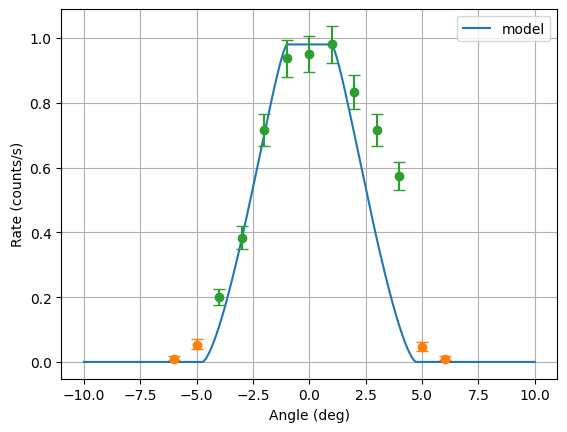

In [6]:
import numpy as np
import matplotlib.pyplot as plt

L1, r1 = 44.45, 4.445/2
L2, r2 = 23.1775, 1.524/2

alpha1 = np.arctan(r1 / L1)
alpha2 = np.arctan(r2 / L2)


Leff = (L1 * L2) / (L1 + L2)
r1_eff = Leff * np.tan(alpha1)
r2_eff = Leff * np.tan(alpha2)

def circle_overlap(d, r1, r2):
    if d >= r1 + r2:
        return 0.0
    if d <= abs(r1 - r2):
        return np.pi * min(r1, r2)**2

    a = np.arccos((r1**2 + d**2 - r2**2) / (2 * r1 * d))
    b = np.arccos((r2**2 + d**2 - r1**2) / (2 * r2 * d))

    return (
        r1**2 * a +
        r2**2 * b -
        0.5 * np.sqrt((-d + r1 + r2) *
                      ( d + r1 - r2) *
                      ( d - r1 + r2) *
                      ( d + r1 + r2))
    )

ang = np.linspace(-10, 10, 400)
theta = np.radians(ang)
d = Leff * np.tan(theta)
model = np.array([circle_overlap(abs(di), r1_eff, r2_eff) for di in d])
model /= model.max()
model *= np.max(high_rates + low_rates)
plt.plot(ang, model, label="model")

plt.errorbar(low_angles, low_rates,
             yerr=[low_err_low, low_err_high],
             fmt='o', capsize=4)

plt.errorbar(high_angles, high_rates,
             yerr=high_err,
             fmt='o', capsize=4)

plt.xlabel("Angle (deg)")
plt.ylabel("Rate (counts/s)")
plt.grid(True)
plt.legend()
plt.show()

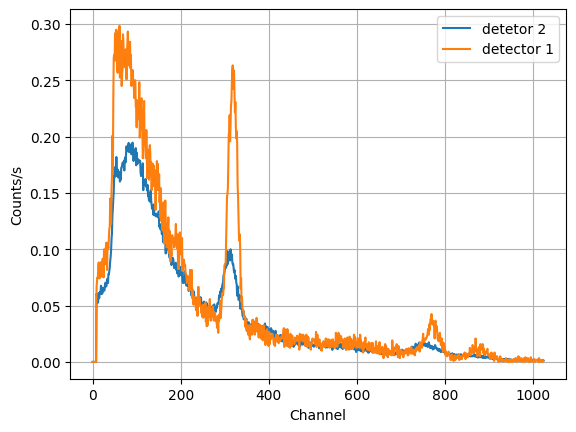

In [7]:
coince_on = load_spectrum("GpC26/20degrees20minutesgateon.csv")
coince_off = load_spectrum("GpC26/counter1_20deg_20min_nogate.csv")
detect2 = load_spectrum("GpC26/counter2_2h.csv")


plt.plot(detect2['Counts']/7600, label ="detetor 2")
plt.plot(coince_off['Counts']/1200,label ="detector 1")


plt.xlabel("Channel")
plt.ylabel("Counts/s")
plt.grid()
plt.legend()
plt.show()

,Angle (deg),Counts (N),Unc - (counts),Unc + (counts),Rate (counts/s),Unc - (counts/s),Unc + (counts/s)
0,-6,0,0.00,1.84,0.00000,0.00000,0.00613
1,-5,0,0.00,1.84,0.00000,0.00000,0.00613
2,-4,0,0.00,1.84,0.00000,0.00000,0.00613
3,-3,0,0.00,1.84,0.00000,0.00000,0.00613
4,-2,0,0.00,1.84,0.00000,0.00000,0.00613
5,-1,0,0.00,1.84,0.00000,0.00000,0.00613
6,0,0,0.00,1.84,0.00000,0.00000,0.00613
7,1,0,0.00,1.84,0.00000,0.00000,0.00613
8,2,1,0.83,2.30,0.00333,0.00277,0.00767
9,3,0,0.00,1.84,0.00000,0.00000,0.00613


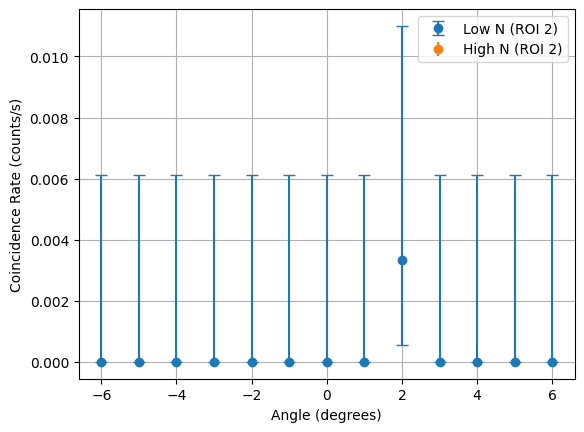

In [8]:
low_angles2, low_rates2, low_err_low2, low_err_high2 = [], [], [], []
high_angles2, high_rates2, high_err2 = [], [], []
rows2 = []

for angle, df in sorted(angle_data.items()):
    N2 = df[(df["Channel"].between(730, 820))]["Counts"].sum()
    R2 = N2 / run_time
    
    if N2 < 50 and N2 in poisson_68_table:
        low, high = poisson_68_table[N2]
        e_low, e_high = (N2 - low)/run_time, (high - N2)/run_time
        low_angles2.append(angle)
        low_rates2.append(R2)
        low_err_low2.append(e_low)
        low_err_high2.append(e_high)
        unc_counts_low, unc_counts_high = N2 - low, high - N2
        sigma_low, sigma_high = e_low, e_high
    else:
        e = np.sqrt(N2)
        high_angles2.append(angle)
        high_rates2.append(R2)
        high_err2.append(e/run_time)
        unc_counts_low = unc_counts_high = e
        sigma_low = sigma_high = e / run_time

    rows2.append({
        "Angle (deg)": angle,
        "Counts (N)": int(N2),
        "Unc - (counts)": round(unc_counts_low, 3),
        "Unc + (counts)": round(unc_counts_high, 3),
        "Rate (counts/s)": round(R2, 5),
        "Unc - (counts/s)": round(sigma_low, 5),
        "Unc + (counts/s)": round(sigma_high, 5)
    })

table2 = pd.DataFrame(rows2).sort_values("Angle (deg)")
display(table2)

plt.errorbar(low_angles2, low_rates2, yerr=[low_err_low2, low_err_high2], fmt='o', capsize=4, label="Low N (ROI 2)")
plt.errorbar(high_angles2, high_rates2, yerr=high_err2, fmt='o', capsize=4, label="High N (ROI 2)")
plt.xlabel("Angle (degrees)")
plt.ylabel("Coincidence Rate (counts/s)")
plt.legend()
plt.grid(True)
plt.show()


In [9]:

import numpy as np

def get_roi_counts(df, low_channel=280, high_channel=350):
    roi = df[df["Channel"].between(low_channel, high_channel)]
    return roi["Counts"].sum()
def poisson_bounds(N, poisson_68_table):
    """
    Returns asymmetric (low, high) bounds for Poisson.
    Falls back to sqrt(N) if not in table.
    """
    if N in poisson_68_table:
        low, high = poisson_68_table[N]
        return low, high
    else:
        sigma = np.sqrt(N)
        return N - sigma, N + sigma


t1 = 1200
t2 = 7600

N_on = get_roi_counts(coince_on)
N_off = get_roi_counts(coince_off)
N_2 = get_roi_counts(detect2)
tau = (N_on * t2) / (N_off * N_2)
rel_err = np.sqrt(1/N_on + 1/N_off + 1/N_2)
tau_gauss_err = tau * rel_err



on_low, on_high = poisson_bounds(N_on, poisson_68_table)
off_low, off_high = poisson_bounds(N_off, poisson_68_table)
n2_low, n2_high = poisson_bounds(N_2, poisson_68_table)

tau_plus = (on_high * t2) / (off_low * n2_low)
tau_minus = (on_low * t2) / (off_high * n2_high)

tau_err_plus = tau_plus - tau
tau_err_minus = tau - tau_minus

print(f"tau (Gaussian) = {tau:.3e} ± {tau_gauss_err:.1e} s")
print(f"tau (asymmetric) = {tau:.3e} +{tau_err_plus:.1e} -{tau_err_minus:.1e} s")

tau (Gaussian) = 2.164e-05 ± 2.2e-05 s
tau (asymmetric) = 2.164e-05 +5.1e-05 -1.8e-05 s
